1. Gerando o dataset sintético de EEG...
Dataset gerado com sucesso. Formato de X: (200, 3, 750), Formato de y: (200,)


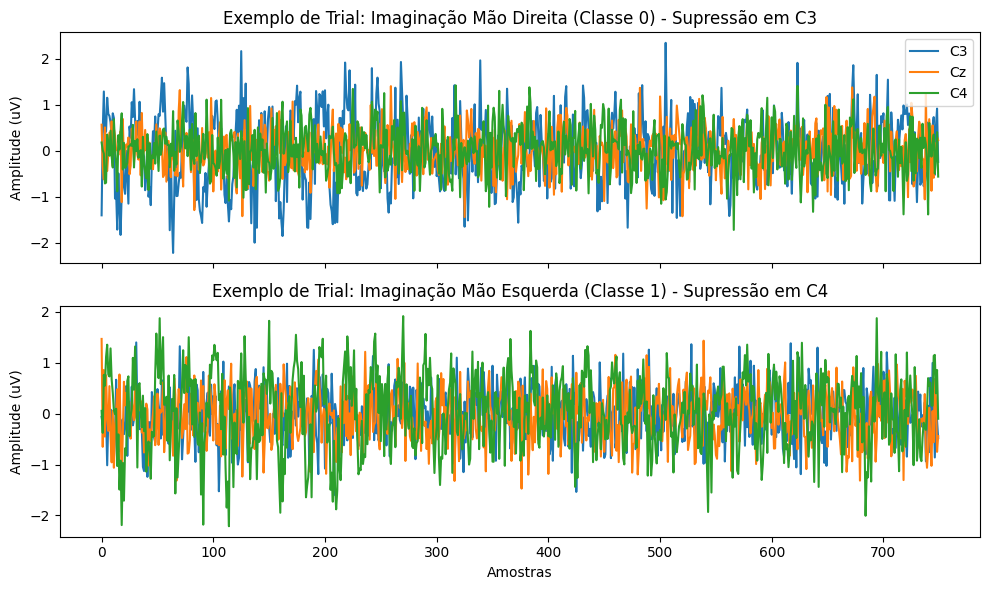


2. Pré-processando e extraindo características...
Características extraídas com sucesso. Novo formato de X: (200, 3)
Exemplo de vetor de características para o primeiro trial: [0.25800445 0.00675917 0.01038202]

3. Treinando o classificador SVM...
Treinamento concluído.

4. Avaliando o modelo treinado...
Acurácia no conjunto de teste: 1.00

Relatório de Classificação:
              precision    recall  f1-score   support

 Mão Direita       1.00      1.00      1.00        30
Mão Esquerda       1.00      1.00      1.00        30

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60


Matriz de Confusão:


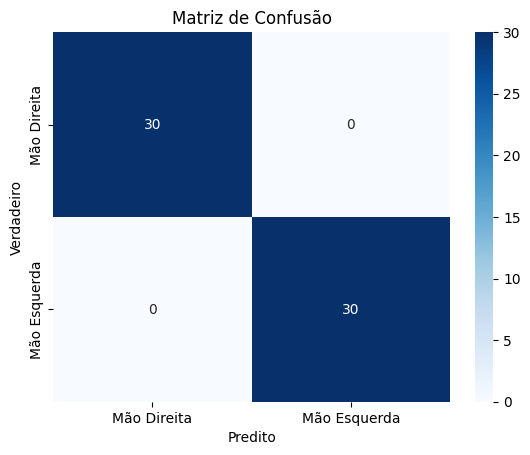

In [1]:
import numpy as np
from scipy import signal
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Geração do Dataset Sintético ---
print("1. Gerando o dataset sintético de EEG...")

def gerar_trial_eeg(duracao, taxa_amostragem, canal_ativo_idx, freq_alfa=10.5, supressao=0.5):
    """
    Gera um único trial de EEG simulado com supressão em uma banda de frequência específica.
    """
    num_amostras = int(duracao * taxa_amostragem)
    tempo = np.linspace(0, duracao, num_amostras, endpoint=False)
    num_canais = 3 # C3, Cz, C4

    # Ruído de fundo (simulando atividade cerebral geral)
    eeg_data = np.random.randn(num_canais, num_amostras) * 0.5

    # Sinal Alfa (mais forte no início, depois suprimido)
    janela_supressao = 1 - (np.hstack([np.zeros(taxa_amostragem), np.ones(num_amostras - taxa_amostragem)]) * supressao)
    sinal_alfa = np.sin(2 * np.pi * freq_alfa * tempo) * janela_supressao

    # Adiciona o sinal alfa ao canal ativo com ruído
    eeg_data[canal_ativo_idx, :] += sinal_alfa
    eeg_data[canal_ativo_idx, :] += np.random.randn(num_amostras) * 0.2

    return eeg_data

# Parâmetros
taxa_amostragem = 250  # Hz
duracao_trial = 3      # segundos
num_trials_por_classe = 100

X = []
y = []

# Classe 0: Mão Direita (supressão em C3 -> índice 0)
for _ in range(num_trials_por_classe):
    X.append(gerar_trial_eeg(duracao_trial, taxa_amostragem, canal_ativo_idx=0))
    y.append(0)

# Classe 1: Mão Esquerda (supressão em C4 -> índice 2)
for _ in range(num_trials_por_classe):
    X.append(gerar_trial_eeg(duracao_trial, taxa_amostragem, canal_ativo_idx=2))
    y.append(1)

X = np.array(X)
y = np.array(y)

print(f"Dataset gerado com sucesso. Formato de X: {X.shape}, Formato de y: {y.shape}")

# Visualizar um trial de cada classe para ver a diferença
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(X[0].T)
ax1.set_title('Exemplo de Trial: Imaginação Mão Direita (Classe 0) - Supressão em C3')
ax1.set_ylabel('Amplitude (uV)')
ax1.legend(['C3', 'Cz', 'C4'])
ax2.plot(X[100].T)
ax2.set_title('Exemplo de Trial: Imaginação Mão Esquerda (Classe 1) - Supressão em C4')
ax2.set_xlabel('Amostras')
ax2.set_ylabel('Amplitude (uV)')
plt.tight_layout()
plt.show()


# --- 2. Pré-processamento e Extração de Características ---
print("\n2. Pré-processando e extraindo características...")

def extrair_potencia_banda(trial, taxa_amostragem, banda_freq=(8, 13)):
    """
    Calcula a potência média em uma banda de frequência para cada canal.
    Isso é um método comum de extração de características (Band Power).
    """
    features = []
    for canal_data in trial:
        # Aplica um filtro Butterworth passa-banda
        sos = signal.butter(5, banda_freq, 'bandpass', fs=taxa_amostragem, output='sos')
        sinal_filtrado = signal.sosfilt(sos, canal_data)
        
        # Calcula a potência (variância do sinal filtrado)
        potencia = np.var(sinal_filtrado)
        features.append(potencia)
    return features

# Extrai as características para todos os trials
X_features = np.array([extrair_potencia_banda(trial, taxa_amostragem) for trial in X])

print(f"Características extraídas com sucesso. Novo formato de X: {X_features.shape}")
print("Exemplo de vetor de características para o primeiro trial:", X_features[0])


# --- 3. Treinamento do Classificador SVM ---
print("\n3. Treinando o classificador SVM...")

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.3, random_state=42, stratify=y
)

# Criação do Pipeline do SVM
# 1. StandardScaler: Normaliza os dados (importante para o SVM)
# 2. SVC: O classificador SVM com um kernel RBF (bom para relações não-lineares)
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='auto', probability=True))
])

# Treinamento do modelo
pipeline_svm.fit(X_train, y_train)

print("Treinamento concluído.")


# --- 4. Avaliação do Modelo ---
print("\n4. Avaliando o modelo treinado...")

# Fazer previsões no conjunto de teste
y_pred = pipeline_svm.predict(X_test)

# Calcular a acurácia
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia no conjunto de teste: {acuracia:.2f}")

# Mostrar o relatório de classificação
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Mão Direita', 'Mão Esquerda']))

# Mostrar a Matriz de Confusão
print("\nMatriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Mão Direita', 'Mão Esquerda'],
            yticklabels=['Mão Direita', 'Mão Esquerda'])
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()